# Router Convergence Comparison

Compares **Identity**, **Linear**, and **Carson** routers on CIFAR-10 and Speech Commands.
When multiple runs exist for a router, the shaded band shows ± 1 std across runs.

**Outputs:**
- `figures/cifar10_convergence_comparison.png`
- `figures/speech_commands_convergence_comparison.png`

## Configuration

In [6]:
main_experiment_name = "core_experiments"
sub_experiment_name  = "full_routing"
model_name           = "cats"

DATASETS      = ["cifar10", "speech_commands"]
ROUTING_TYPES = ["identity", "linear", "carson"]
ALL_RUNS      = ["run_001", "run_002"]   # auto-discovery will skip missing ones

ROUTER_COLORS = {
    "identity": "tab:blue",
    "linear":   "tab:orange",
    "carson":   "tab:green",
}
ROUTER_LABELS = {
    "identity": "Identity",
    "linear":   "Linear",
    "carson":   "Carson",
}

# Metrics shown in each comparison panel
METRICS = [
    ("val_loss",  "Val Loss",     False),
    ("val_acc",   "Val Accuracy", True),
    ("val_f1",    "Val F1",       True),
    ("train_f1",  "Train F1",     True),
]

## Imports & Paths

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from pathlib import Path

ROOT    = Path().resolve().parent.parent.parent
OUT_DIR = Path().resolve() / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12})

print(f"Project root : {ROOT}")
print(f"Figures dir  : {OUT_DIR}")

Project root : C:\Users\Zohoor Almalki\Projects\CATS
Figures dir  : C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures


## Load Training Logs

In [10]:
def load_runs(dataset: str, routing_type: str) -> list[pd.DataFrame]:
    """Return one DataFrame per available run for this dataset/router."""
    dfs = []
    for run_name in ALL_RUNS:
        log_path = (
            ROOT / "logs" / main_experiment_name / sub_experiment_name
            / dataset / model_name / routing_type / run_name / "train_log.csv"
        )
        if log_path.exists():
            df = pd.read_csv(log_path)
            df["run_name"] = run_name
            dfs.append(df)
    return dfs


def aggregate_runs(dfs: list[pd.DataFrame]) -> pd.DataFrame | None:
    """Mean ± std per epoch across runs; returns None if no data."""
    if not dfs:
        return None
    combined = pd.concat(dfs, ignore_index=True)
    numeric  = combined.select_dtypes(include=np.number).columns.tolist()
    agg = (
        combined.groupby("epoch")[numeric]
        .agg(["mean", "std"])
        .reset_index()
    )
    return agg

In [11]:
all_data: dict[str, dict] = {}

for dataset in DATASETS:
    all_data[dataset] = {}
    for routing_type in ROUTING_TYPES:
        runs = load_runs(dataset, routing_type)
        all_data[dataset][routing_type] = {
            "runs":   runs,
            "agg":    aggregate_runs(runs),
            "n_runs": len(runs),
        }
        status = f"{len(runs)} run(s)" if runs else "NO DATA"
        print(f"  {dataset:20s} | {routing_type:10s} | {status}")

C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_18908\1734985357.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


  cifar10              | identity   | 1 run(s)
  cifar10              | linear     | 1 run(s)
  cifar10              | carson     | 1 run(s)
  speech_commands      | identity   | 1 run(s)
  speech_commands      | linear     | 1 run(s)
  speech_commands      | carson     | 1 run(s)


## Plotting Helper

In [12]:
def plot_convergence_comparison(
    dataset: str,
    metrics: list | None = None,
    figsize: tuple = (18, 4.5),
) -> plt.Figure:
    """Multi-panel convergence comparison for all routers on one dataset."""
    if metrics is None:
        metrics = METRICS

    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, (col, ylabel, higher_is_better) in zip(axes, metrics):
        for routing_type in ROUTING_TYPES:
            info  = all_data[dataset][routing_type]
            agg   = info["agg"]
            if agg is None:
                continue

            # column may not exist for all routers (e.g. routing_conf for identity)
            top_cols = agg.columns.get_level_values(0)
            if col not in top_cols:
                continue

            color  = ROUTER_COLORS[routing_type]
            n_runs = info["n_runs"]
            label  = f"{ROUTER_LABELS[routing_type]}" + (f" (×{n_runs})" if n_runs > 1 else "")

            epochs    = agg["epoch"]["mean"].values
            mean_vals = agg[col]["mean"].values
            std_vals  = agg[col]["std"].fillna(0).values

            ax.plot(epochs, mean_vals, color=color, label=label,
                    linewidth=2, marker="o", markersize=4)
            if n_runs > 1:
                ax.fill_between(
                    epochs,
                    mean_vals - std_vals,
                    mean_vals + std_vals,
                    alpha=0.18, color=color,
                )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=9, loc="best")
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    dataset_title = dataset.replace("_", " ").title()
    fig.suptitle(
        f"{dataset_title}  —  Router Convergence Comparison\n"
        f"({main_experiment_name} / {sub_experiment_name})",
        fontsize=13, y=1.03,
    )
    fig.tight_layout()
    return fig


def save_fig(fig: plt.Figure, name: str) -> None:
    path = OUT_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved  →  {path}")

## CIFAR-10 Convergence Comparison

saved  →  C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures\cifar10_convergence_comparison.png


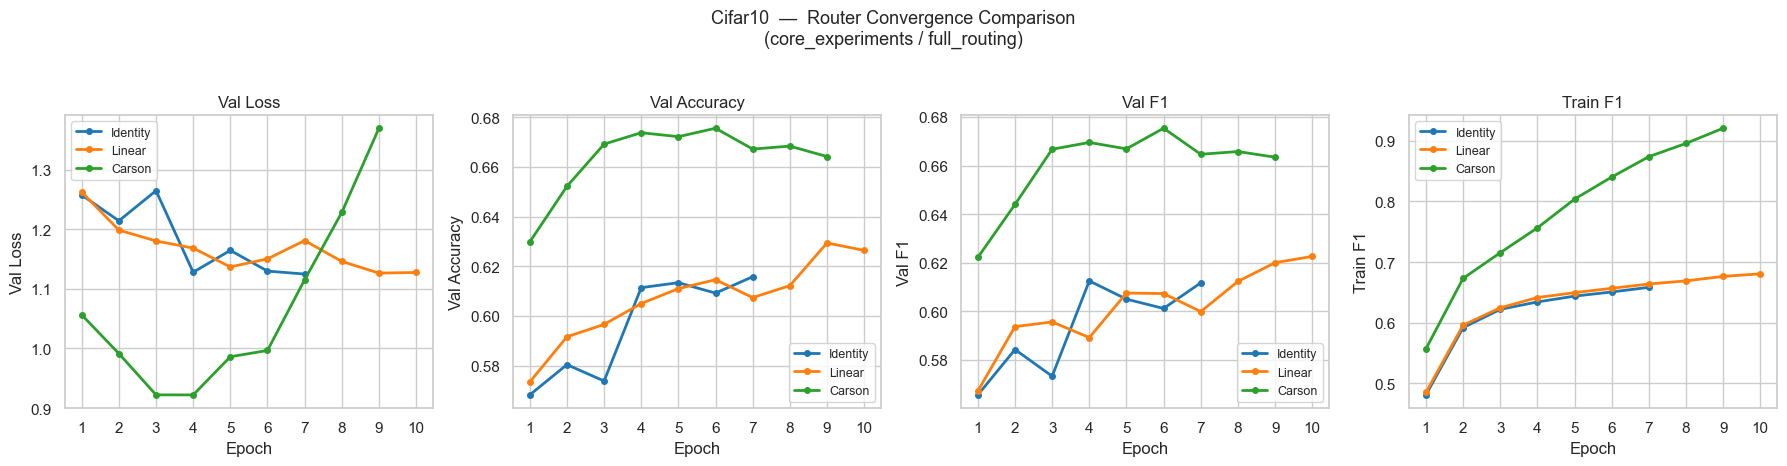

In [13]:
fig_cifar = plot_convergence_comparison("cifar10")
save_fig(fig_cifar, "cifar10_convergence_comparison.png")
plt.show()

## Speech Commands Convergence Comparison

saved  →  C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures\speech_commands_convergence_comparison.png


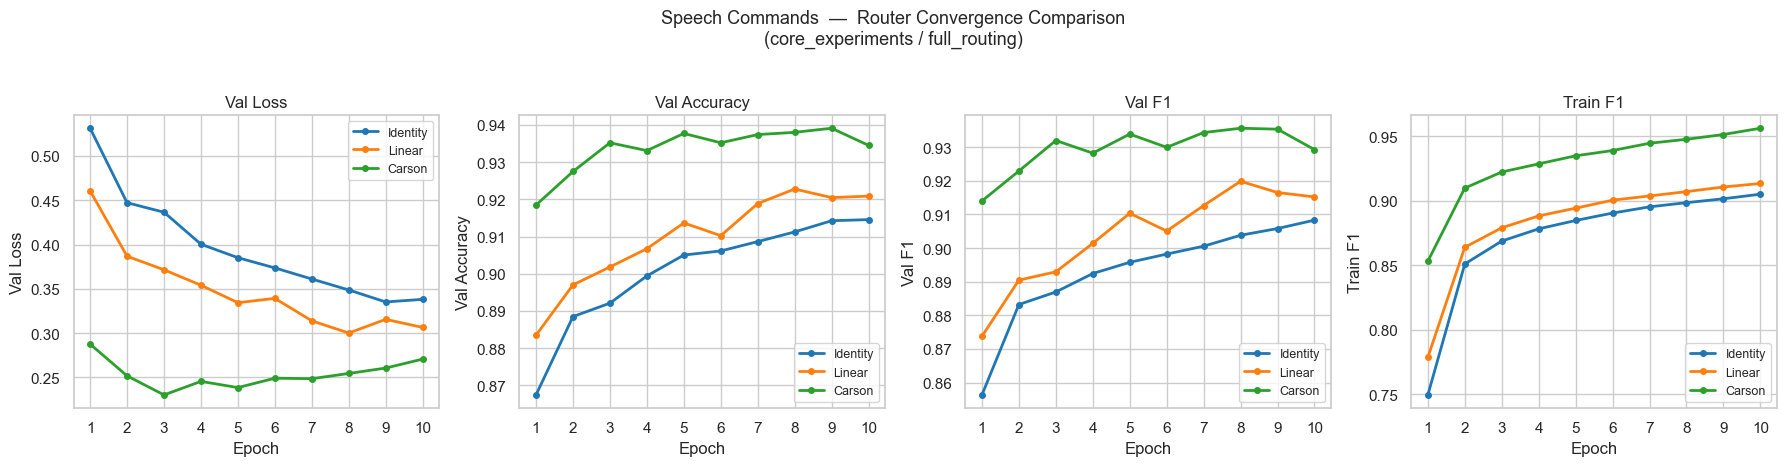

In [14]:
fig_speech = plot_convergence_comparison("speech_commands")
save_fig(fig_speech, "speech_commands_convergence_comparison.png")
plt.show()

## Best-Metric Summary Table

Best validation F1, accuracy, and loss reached per router per dataset.

In [15]:
rows = []
for dataset in DATASETS:
    for routing_type in ROUTING_TYPES:
        info = all_data[dataset][routing_type]
        if info["agg"] is None:
            continue
        agg = info["agg"]
        top = agg.columns.get_level_values(0)

        def best_mean(col, maximize=True):
            if col not in top:
                return float("nan")
            vals = agg[col]["mean"]
            return vals.max() if maximize else vals.min()

        rows.append({
            "Dataset":         dataset,
            "Router":          ROUTER_LABELS[routing_type],
            "Runs":            info["n_runs"],
            "Best Val F1":     round(best_mean("val_f1",  maximize=True),  4),
            "Best Val Acc":    round(best_mean("val_acc", maximize=True),  4),
            "Best Val Loss":   round(best_mean("val_loss",maximize=False), 4),
            "Best Train F1":   round(best_mean("train_f1",maximize=True),  4),
        })

summary = pd.DataFrame(rows).set_index(["Dataset", "Router"])
display(summary)

Runs  Best Val F1  Best Val Acc  Best Val Loss  \
Dataset         Router                                                     
cifar10         Identity     1       0.6125        0.6158         1.1248   
                Linear       1       0.6226        0.6294         1.1264   
                Carson       1       0.6754        0.6756         0.9222   
speech_commands Identity     1       0.9083        0.9145         0.3352   
                Linear       1       0.9199        0.9228         0.3001   
                Carson       1       0.9356        0.9391         0.2303   

                          Best Train F1  
Dataset         Router                   
cifar10         Identity         0.6583  
                Linear           0.6805  
                Carson           0.9204  
speech_commands Identity         0.9052  
                Linear           0.9135  
                Carson           0.9564

## Train vs Val F1 — All Routers

Solid = val, dashed = train; useful to spot over/under-fitting per router.

saved  →  C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures\cifar10_train_val_f1_comparison.png


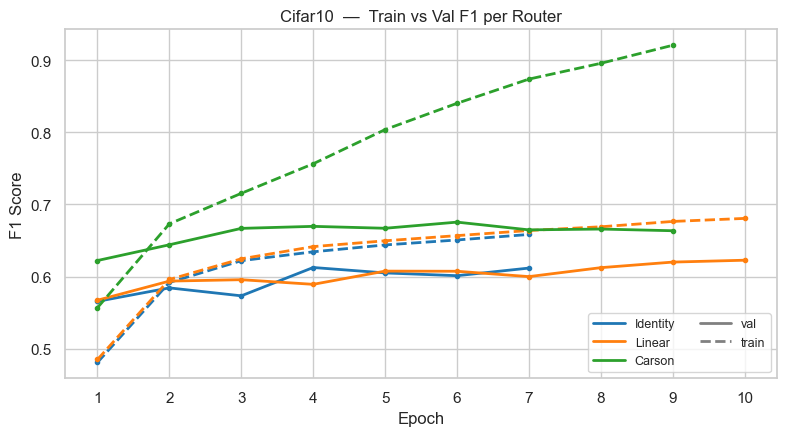

saved  →  C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures\speech_commands_train_val_f1_comparison.png


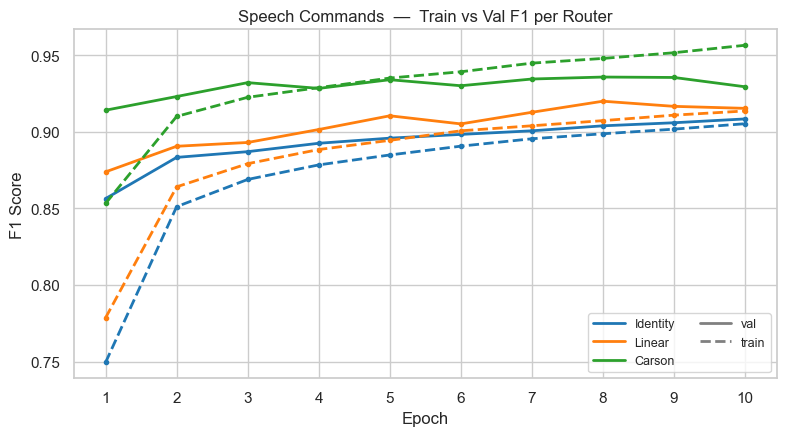

In [16]:
def plot_train_val_f1(dataset: str, figsize: tuple = (8, 4.5)) -> plt.Figure:
    fig, ax = plt.subplots(figsize=figsize)

    for routing_type in ROUTING_TYPES:
        info = all_data[dataset][routing_type]
        agg  = info["agg"]
        if agg is None:
            continue
        top    = agg.columns.get_level_values(0)
        color  = ROUTER_COLORS[routing_type]
        epochs = agg["epoch"]["mean"].values

        for col, ls in [("val_f1", "-"), ("train_f1", "--")]:
            if col not in top:
                continue
            mean_vals = agg[col]["mean"].values
            std_vals  = agg[col]["std"].fillna(0).values
            ax.plot(epochs, mean_vals, color=color, linestyle=ls,
                    linewidth=2, marker="o", markersize=3)
            if info["n_runs"] > 1:
                ax.fill_between(epochs,
                                mean_vals - std_vals,
                                mean_vals + std_vals,
                                alpha=0.12, color=color)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 Score")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # Two-part legend: color = router, linestyle = val/train
    router_handles = [
        mlines.Line2D([], [], color=ROUTER_COLORS[r], linewidth=2, label=ROUTER_LABELS[r])
        for r in ROUTING_TYPES
    ]
    style_handles = [
        mlines.Line2D([], [], color="gray", linestyle="-",  linewidth=2, label="val"),
        mlines.Line2D([], [], color="gray", linestyle="--", linewidth=2, label="train"),
    ]
    ax.legend(handles=router_handles + style_handles,
              fontsize=9, ncol=2, loc="lower right", handlelength=2.5)

    dataset_title = dataset.replace("_", " ").title()
    ax.set_title(f"{dataset_title}  —  Train vs Val F1 per Router", fontsize=12)
    fig.tight_layout()
    return fig


for ds in DATASETS:
    fig = plot_train_val_f1(ds)
    save_fig(fig, f"{ds}_train_val_f1_comparison.png")
    plt.show()

## Loss Decomposition per Router

Shows task loss, balance loss, and entropy loss for each router (where available).

saved  →  C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures\cifar10_loss_decomposition_comparison.png


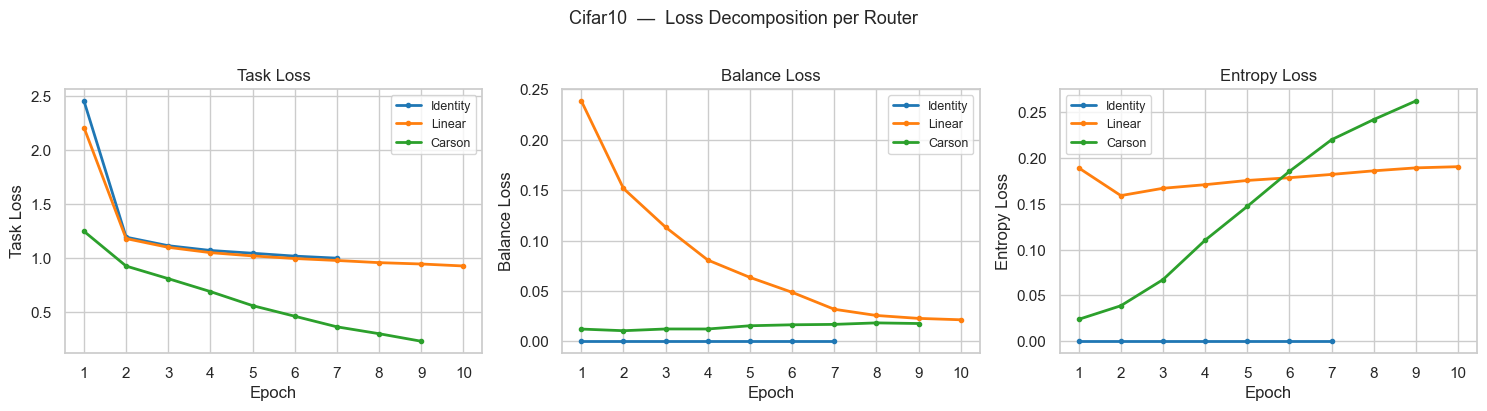

saved  →  C:\Users\Zohoor Almalki\Projects\CATS\results\core_experiments_analysis\shared_analysis\figures\speech_commands_loss_decomposition_comparison.png


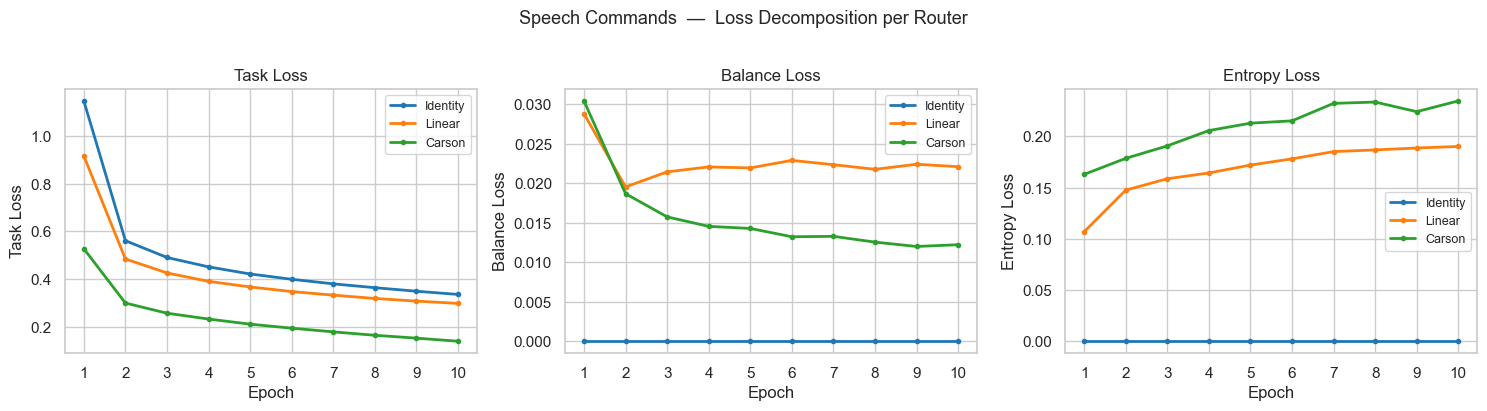

In [17]:
LOSS_METRICS = [
    ("train_task_loss",    "Task Loss"),
    ("train_balance_loss", "Balance Loss"),
    ("train_entropy_loss", "Entropy Loss"),
]

for dataset in DATASETS:
    dataset_title = dataset.replace("_", " ").title()
    fig, axes = plt.subplots(1, len(LOSS_METRICS), figsize=(15, 4))

    for ax, (col, ylabel) in zip(axes, LOSS_METRICS):
        for routing_type in ROUTING_TYPES:
            info = all_data[dataset][routing_type]
            agg  = info["agg"]
            if agg is None:
                continue
            top = agg.columns.get_level_values(0)
            if col not in top:
                continue

            color     = ROUTER_COLORS[routing_type]
            label     = ROUTER_LABELS[routing_type]
            epochs    = agg["epoch"]["mean"].values
            mean_vals = agg[col]["mean"].values
            std_vals  = agg[col]["std"].fillna(0).values

            ax.plot(epochs, mean_vals, color=color, label=label,
                    linewidth=2, marker="o", markersize=3)
            if info["n_runs"] > 1:
                ax.fill_between(epochs,
                                mean_vals - std_vals,
                                mean_vals + std_vals,
                                alpha=0.15, color=color)

        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=9)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    fig.suptitle(f"{dataset_title}  —  Loss Decomposition per Router", fontsize=13, y=1.02)
    fig.tight_layout()
    save_fig(fig, f"{dataset}_loss_decomposition_comparison.png")
    plt.show()

---
All figures saved to `figures/`.